# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Jaya Jaya Data Scientist
- Email: data@jayajaya.edu
- Id Dicoding: jayajaya_ds

## Persiapan
Tahap ini mencakup penyiapan library dan data yang akan digunakan selama proses analisis dan pemodelan.

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding
Pada tahap ini kita akan mengeksplorasi dataset, melihat jumlah baris, kolom, serta distribusi target (Status).

Shape dataset: (4424, 37)

Distribusi Target (Status):
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


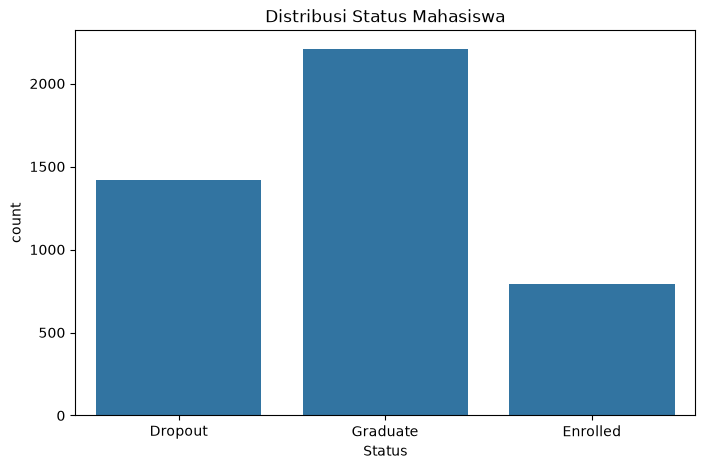

In [3]:
print("Shape dataset:", df.shape)
print("\nDistribusi Target (Status):")
print(df['Status'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Status')
plt.title('Distribusi Status Mahasiswa')
plt.show()

Insight: Dataset memiliki 4424 baris. Target variabel didominasi oleh kelas 'Graduate', lalu 'Dropout', dan 'Enrolled'.

## Data Preparation / Preprocessing
Kita akan membuang status 'Enrolled' agar pemodelan fokus pada klasifikasi mahasiswa yang lulus (Graduate) dan putus sekolah (Dropout). Kita juga akan encode variabel target.

In [4]:
# Cek missing values
print("Jumlah missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Filter data, hapus 'Enrolled'
df_model = df[df['Status'] != 'Enrolled'].copy()

# Encoding target: Dropout=0, Graduate=1
df_model['Status_Binary'] = df_model['Status'].map({'Dropout': 0, 'Graduate': 1})
df_model.drop(columns=['Status'], inplace=True)

X = df_model.drop(columns=['Status_Binary'])
y = df_model['Status_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Jumlah missing values:
 Series([], dtype: int64)


## Modeling
Kita akan menggunakan algoritma Random Forest Classifier karena performanya yang baik dan tidak memerlukan scalling yang berlebihan.

In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Simpan model
import os
os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/rf_model.joblib')

['model/rf_model.joblib']

## Evaluation
Tahap terakhir adalah mengevaluasi performa model menggunakan testing set.

Accuracy: 0.9022038567493113

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87       277
           1       0.90      0.95      0.92       449

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



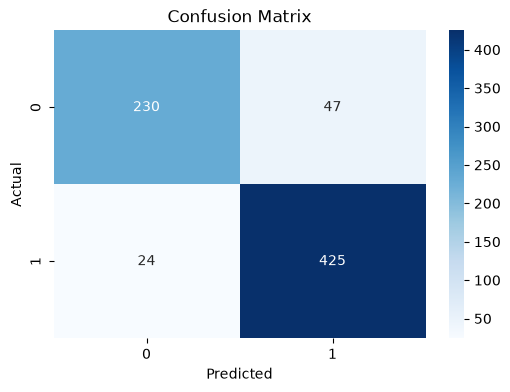

In [6]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()